In [139]:
import pandas as pd
df = pd.read_csv('DS_BreastCancer.csv')
# Display all column names
columns = df.columns.tolist()
print(columns)

['chembl_id', 'molregno', 'iupac_name', 'smiles', 'molecular_weight', 'aLogP', 'hba', 'hbd', 'psa', 'rtb', 'ro3_pass', 'num_ro5_violations', 'cx_logp', 'cx_logd', 'molecular_species', 'qed_weighted', 'np_likeness_score', 'ic50_value', 'ic50_units', 'standard_relation', 'target_name', 'target_type', 'cell_description', 'disease_name', 'disease_category', 'mechanism_of_action', 'action_type', 'warning_type', 'warning_description', 'IUPACName']


/var/folders/ky/j161912n7lvbtpf0r6nlk1xh0000gn/T/ipykernel_1760/721474221.py:2: DtypeWarning: Columns (0: warning_description) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('DS_BreastCancer.csv')


In [140]:
import numpy as np

In [ ]:
#removed unnecessary columns
df1 = df[['smiles', 'molecular_weight', 'aLogP', 'hba', 'hbd', 'psa', 'rtb', 'ic50_value', 'ic50_units']]

In [142]:
# Remove all null values from df1
df1 = df1.dropna()
print(f"Shape after removing nulls: {df1.shape}")
print(df1.info())

Shape after removing nulls: (43617, 9)
<class 'pandas.DataFrame'>
Index: 43617 entries, 0 to 46290
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            43617 non-null  str    
 1   molecular_weight  43617 non-null  float64
 2   aLogP             43617 non-null  float64
 3   hba               43617 non-null  float64
 4   hbd               43617 non-null  float64
 5   psa               43617 non-null  float64
 6   rtb               43617 non-null  float64
 7   ic50_value        43617 non-null  float64
 8   ic50_units        43617 non-null  str    
dtypes: float64(7), str(2)
memory usage: 3.3 MB
None


In [ ]:
#checked whether the units of IC50 values are th sane
print(df1['ic50_units'].unique())

<StringArray>
['nM', 'ug.mL-1', 'ug', 'ug/g', '%', 'pmol/L', '10'5uM', '10'6uM', '10^3nM']
Length: 9, dtype: str


In [ ]:
# Keep only rows with nM units
units_to_keep = ['nM']
df1 = df1[df1['ic50_units'].isin(units_to_keep)]
print(f"Shape after filtering: {df1.shape}")
print(df1['ic50_units'].value_counts())

Shape after filtering: (41691, 9)
ic50_units
nM    41691
Name: count, dtype: int64


In [145]:
df1.info()

<class 'pandas.DataFrame'>
Index: 41691 entries, 0 to 46290
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            41691 non-null  str    
 1   molecular_weight  41691 non-null  float64
 2   aLogP             41691 non-null  float64
 3   hba               41691 non-null  float64
 4   hbd               41691 non-null  float64
 5   psa               41691 non-null  float64
 6   rtb               41691 non-null  float64
 7   ic50_value        41691 non-null  float64
 8   ic50_units        41691 non-null  str    
dtypes: float64(7), str(2)
memory usage: 3.2 MB


In [ ]:
#added the pIC50 column
df1['pic50'] = -np.log10(df1['ic50_value']*1e-9)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Removed 2 rows with max pIC50 = 13.698970004336019
Shape after removing infinite values and max pIC50 outliers: (41687, 10)


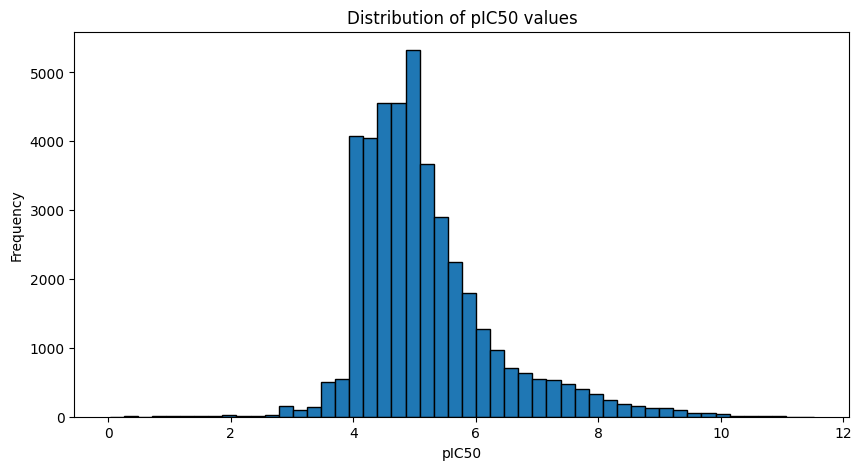

In [ ]:
# Remove infinite or NaN values
df1 = df1[np.isfinite(df1['pic50'])]

# Remove all rows with the maximum pIC50 value as outliers (I saw this at the box plot)
max_pic50 = df1['pic50'].max()
removed_count = df1[df1['pic50'] == max_pic50].shape[0]
df1 = df1[df1['pic50'] != max_pic50]
print(f"Removed {removed_count} rows with max pIC50 = {max_pic50}")
print(f"Shape after removing infinite values and max pIC50 outliers: {df1.shape}")

# Visualize the distribution of pIC50 values
plt.figure(figsize=(10, 5))
plt.hist(df1['pic50'], bins=50, edgecolor='black')
plt.xlabel('pIC50')
plt.ylabel('Frequency')
plt.title('Distribution of pIC50 values')
plt.show()

#distribution is close to normal

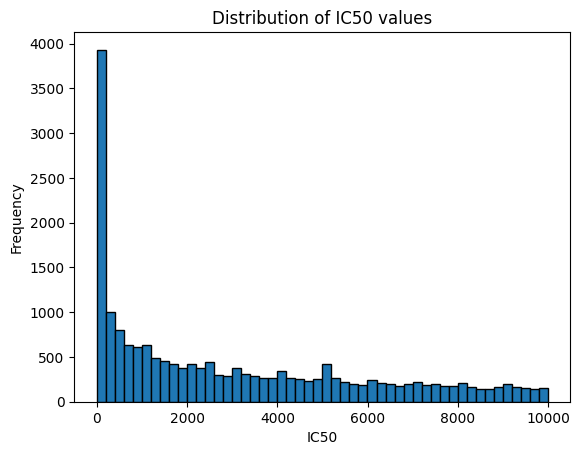

In [ ]:
# Visualize the distribution of IC50 values (in nM)
plt.hist(df1['ic50_value'][df1['ic50_value']<10000], bins=50, edgecolor='black')
plt.xlabel('IC50')
plt.ylabel('Frequency')
plt.title('Distribution of IC50 values')
plt.show()

#from these 2 graphs it is obvious that pIC50 distr is better for machine learning than IC50 values distr

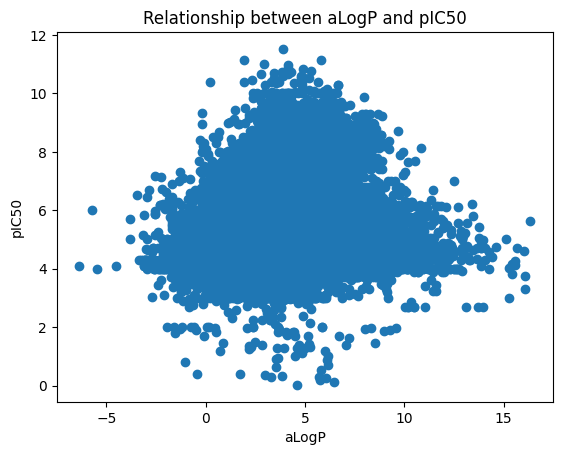

In [ ]:
# Visualize the relationship between aLogP and pIC50
plt.scatter(df1['aLogP'], df1['pic50'])
plt.xlabel('aLogP')
plt.ylabel('pIC50')
plt.title('Relationship between aLogP and pIC50')
plt.show()
#most active compounds (high pIC50) have approx 2<aLogP<7, which corresponds toLipinski's Rule of 5

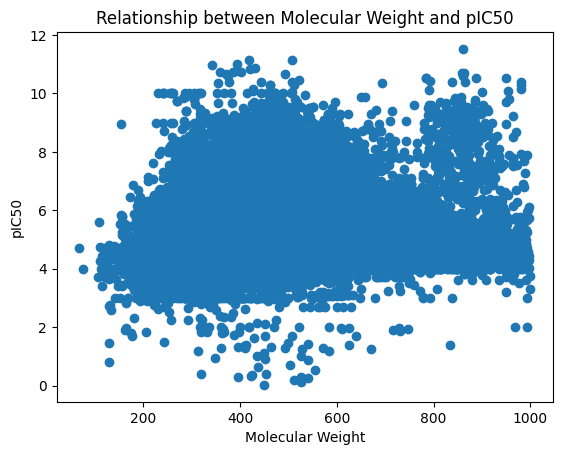

In [ ]:
# Visualize the relationship between molecular weight and pIC50
plt.scatter(df1['molecular_weight'], df1['pic50'])
plt.xlabel('Molecular Weight')
plt.ylabel('pIC50')
plt.title('Relationship between Molecular Weight and pIC50')
plt.show()

#most active compounds (high pIC50) have approx 200<molecular_weight<500 (small molecules don't have the required affinity to target proteins; large molecules get into cells with difficulty)

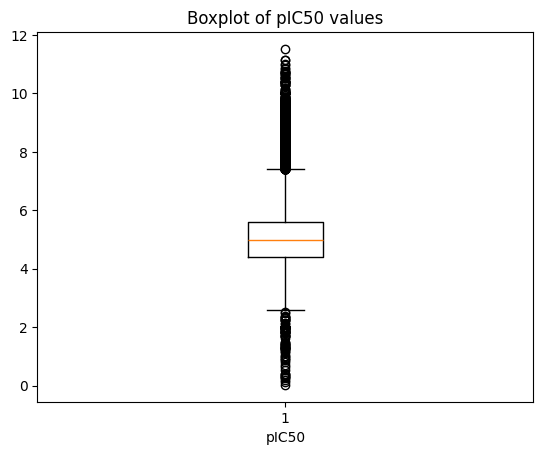

In [ ]:
# Visualize the boxplot of pIC50 values
plt.boxplot(df1['pic50'])
plt.xlabel('pIC50')
plt.title('Boxplot of pIC50 values')
plt.show()

#there was an obvious outlier at 13.8, I removed it earlier

In [152]:
df1['ic50_value'].describe()

count    4.168700e+04
mean     2.401592e+05
std      9.548970e+06
min      3.000000e-03
25%      2.500000e+03
50%      1.043000e+04
75%      4.000000e+04
max      9.506048e+08
Name: ic50_value, dtype: float64

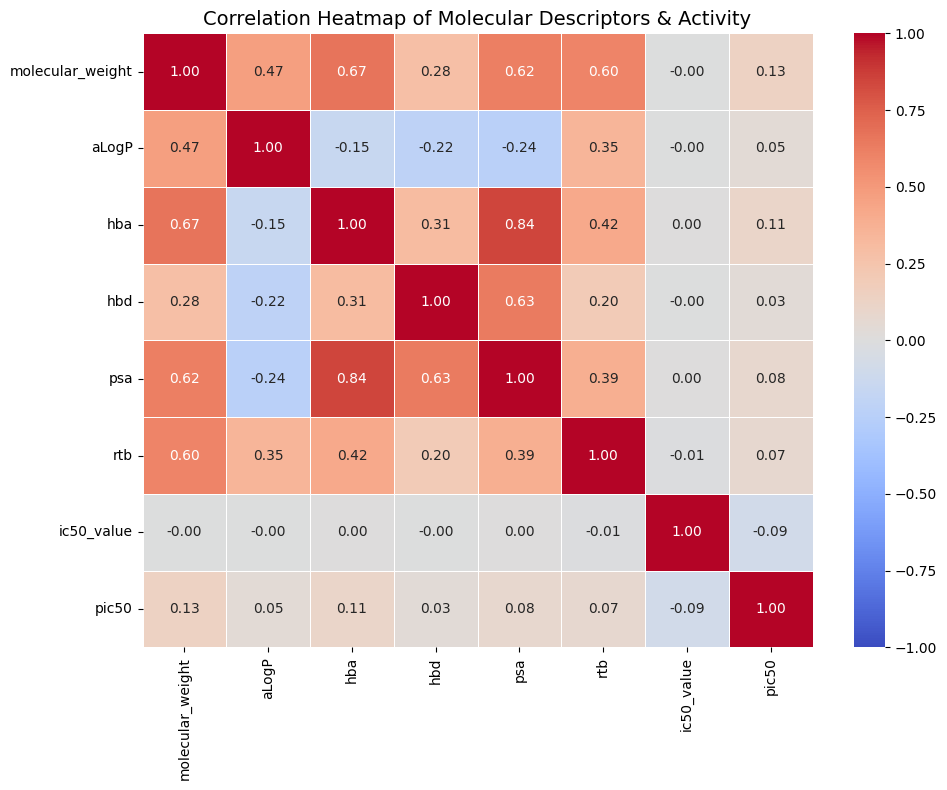

In [ ]:
#creating a heatmap of correlations
import seaborn as sns

# 1. Отбираем только числовые колонки для анализа
# (ic50_value и pic50 сильно связаны, но pic50 линейнее, поэтому оставим все для проверки)
numeric_cols = [
    "molecular_weight",
    "aLogP",
    "hba",
    "hbd",
    "psa",
    "rtb",
    "ic50_value",
    "pic50",
]
corr_matrix = df1[numeric_cols].corr(method="pearson")

# 2. Настраиваем размер полотна
plt.figure(figsize=(10, 8))

# 3. Строим тепловую карту
sns.heatmap(
    corr_matrix,
    annot=True,  # Выводить коэффициенты внутри ячеек
    cmap="coolwarm",  # Красивая палитра: синий (минус) -> белый (ноль) -> красный (плюс)
    fmt=".2f",  # Округление до 2 знаков после запятой
    linewidths=0.5,  # Расстояние между ячейками
    vmin=-1,
    vmax=1,  # Границы шкалы
)

# 4. Добавляем заголовки
plt.title("Correlation Heatmap of Molecular Descriptors & Activity", fontsize=14)
plt.tight_layout()

# 5. Показываем график
plt.show()

#strong correlation between molecular weight and polar surface area (PSA), since larger molecules tend to have larger surface areas. 
#oderate correlation between aLogP andmolecular weight, since larger molecules often have more hydrophobic regions. 
#strong correlation between hba and hbd, since both are related to the presence of hydrogen bond donors and acceptors in the molecule.
#only -0.09 between pIC50 and ic50_value (cause pIC50 = -log10(IC50), non-linear relationship, see later)

In [ ]:
#checking for pIC50 outliers that I mentioned earlier
a=df1[df1['pic50']==df1['pic50'].max()]
print(len(a))
print(a)

1
                                                  smiles  molecular_weight  \
14274  C/C=C(\C)[C@H]1OC(=O)[C@@H](C)NC(=O)[C@H]([C@@...            860.49   

       aLogP   hba  hbd     psa  rtb  ic50_value ic50_units      pic50  
14274   3.89  10.0  4.0  200.75  7.0       0.003         nM  11.522879  


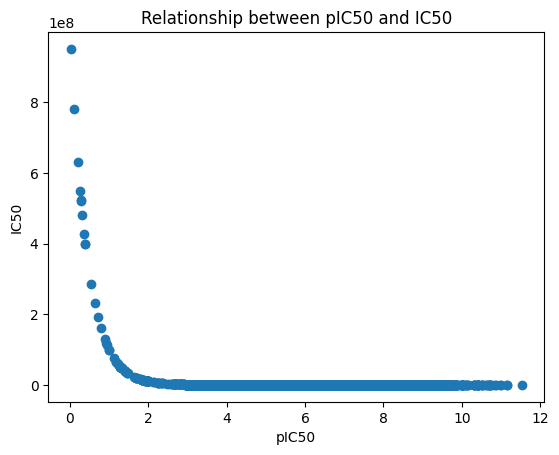

In [ ]:
# Visualize the relationship between pIC50 and IC50 values
plt.scatter(df1['pic50'], df1['ic50_value'])
plt.xlabel('pIC50')
plt.ylabel('IC50')
plt.title('Relationship between pIC50 and IC50')
plt.show()

#clear exponential relationship
#99% of pIC50 values are in 0<IC50<1
#but 1% spoils everything, so ic50_values cannot be used for machine learning at all
#pIC50 should be used instead

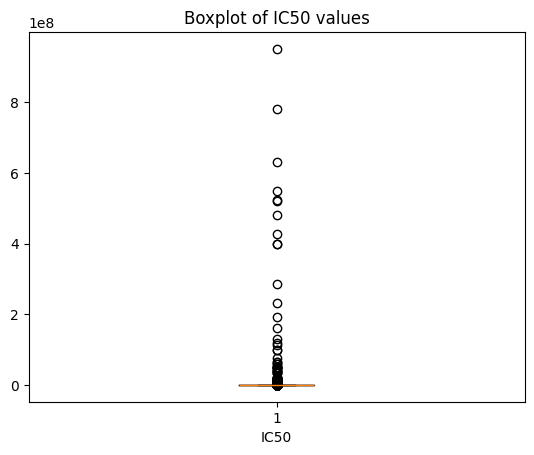

In [ ]:
# Visualize the boxplot of IC50 values
plt.boxplot(df1['ic50_value'])
plt.xlabel('IC50')
plt.title('Boxplot of IC50 values')
plt.show()

#insane number of outliers
#ic50_values cannot be used for machine learning at all, pIC50 should be used instead
#no need for ic50_values and ic50_units columns at this point

In [158]:
df1.info()

<class 'pandas.DataFrame'>
Index: 41687 entries, 0 to 46290
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            41687 non-null  str    
 1   molecular_weight  41687 non-null  float64
 2   aLogP             41687 non-null  float64
 3   hba               41687 non-null  float64
 4   hbd               41687 non-null  float64
 5   psa               41687 non-null  float64
 6   rtb               41687 non-null  float64
 7   ic50_value        41687 non-null  float64
 8   ic50_units        41687 non-null  str    
 9   pic50             41687 non-null  float64
dtypes: float64(8), str(2)
memory usage: 3.5 MB
